# Basis function expansion with the bessel functions

$$ \nabla^2 \Phi (R,z) = 4\pi G \rho(R,z) $$

For systems with a given density profile without corresponding analytical $\Phi (R,z)$, we can turn to a basis function expansion. The bessel functions are advantageous when the systems are very flat $q \lt 3$. 

## Density profile reconstruction

$$ \rho (R,z) = \frac{\Sigma}{2h_z} \exp \left( - \frac{R}{h_R} - \frac{|z|}{h_z} \right) $$

We will explore how the reconstruction improves as we increase the order, for different ratios of $h_R$ to $h_z$. Where $q=\frac{h_R}{h_z}$. Note that this $q$ has a slightly different definition as the flattening for the spheroidal coordinate. 

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib as mpl 
import tstrippy
plt.rcParams.update(
    {
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "font.size": 12,
    }
)

In [2]:
def make_nx4_panel(
    nrows,
    page_width=8.25,
    margin_left=0.8,
    margin_right=0.4,
    margin_bottom=0.5,
    margin_top=0.25,
    gap=0.18,
    y_label_space=0.75,
    x_label_space=0.45,
    title_space=2.5,
    xlabel=None,
    ylabel=None,
    title=None,
):
    """Build touching nrows x 4 layout with a centre gap between columns 2 and 3."""
    usable_w = page_width - margin_left - margin_right
    panel = (usable_w - gap - y_label_space) / 4.0
    if panel <= 0:
        raise ValueError("Panel size <= 0. Increase page width or reduce margins/spaces.")

    fig_h = margin_bottom + x_label_space + nrows * panel + title_space + margin_top
    fig = plt.figure(figsize=(page_width, fig_h))
    axes = np.empty((nrows, 4), dtype=object)

    x0 = margin_left + y_label_space
    y0 = margin_bottom + x_label_space
    for r in range(nrows):
        for c in range(4):
            x_in = x0 + c * panel + (gap if c >= 2 else 0.0)
            y_in = y0 + (nrows - 1 - r) * panel
            ax = fig.add_axes(
                [x_in / page_width, y_in / fig_h, panel / page_width, panel / fig_h]
            )
            ax.set_box_aspect(1.0)
            if r < nrows - 1:
                ax.tick_params(labelbottom=False)
            if c > 0:
                ax.tick_params(labelleft=False)
            axes[r, c] = ax

    if xlabel is not None:
        xc = (x0 + 2.0 * panel + 0.5 * gap) / page_width
        fig.supxlabel(xlabel, x=xc, y=(margin_bottom + 0.40 * x_label_space) / fig_h)
    if ylabel is not None:
        fig.supylabel(ylabel, x=(margin_left + 0.45 * y_label_space) / page_width)
    if title is not None:
        yt = (y0 + nrows * panel + 0.50 * title_space) / fig_h
        fig.suptitle(title, y=yt, va="top", ha="center", multialignment="center")

    return fig, axes



In [3]:
# analytical rho 
def exponential_disk(params,x,y,z):
    sigma,hR,hz = params
    R = np.sqrt(x**2 + y**2)
    return (sigma/(2*hz)) * np.exp ( - (R/hR) - np.abs(z)/hz)

In [4]:
# look at slice 
sigma,s,q = 1, 1, 0.3
hz = s*q
hR = s
params = sigma,hR,hz
factor = 10
npoints= 100
x,z=np.linspace(-factor*s,factor*s,npoints),np.linspace(-factor*s,factor*s,npoints)
X,Z = np.meshgrid(x,z,indexing="xy")
rho = np.zeros_like(X)
for i in range(npoints):
    rho[i] = exponential_disk(params,X[i],np.zeros_like(x),Z[i])

vmin = 1e-5
vmax = 1 
Norm = mpl.colors.LogNorm(vmin=vmin,vmax=vmax)
levels = np.logspace(np.log10(vmin),np.log10(vmax),10)
cmap = mpl.colormaps.get_cmap("magma")

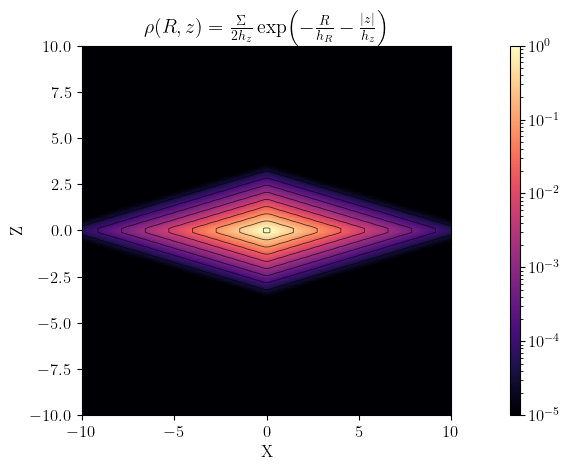

In [5]:
title = r"$\rho(R,z)=  \frac{\Sigma}{2h_z} \exp\!\left( - \frac{R}{h_R} - \frac{|z|}{h_z} \right)$"
fig,axis=plt.subplots(1,2,width_ratios=[50,1],)
okay=axis[0].pcolormesh(X,Z,rho,shading='gouraud',cmap=cmap,norm=Norm)
axis[0].contour(X,Z,rho,levels=levels,colors="k", linewidths=0.6, alpha=0.7)
AXIS={"xlabel":"X","ylabel":"Z","aspect":"equal","title":title}
axis[0].set(**AXIS);
sm = mpl.cm.ScalarMappable(norm=Norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, cax=axis[1])
fig.subplots_adjust(wspace=0,hspace=0)

In [6]:
# Composite Bessel basis setup
G      = 1.0
lmax   = 20
r_grid = np.logspace(-3, 3, 100)
ncomp  = 1
sigma0 = 1.0
hR     = 1.0
hz     = q*hR

# Sanity check
tstrippy.potentials.clearaxisymmetriccompositebasisexpansion()
tstrippy.potentials.initaxisymmetriccompositebasisexpansion(G, lmax, r_grid, ncomp)
tstrippy.potentials.addcompositebesselexponentialdisk(1, sigma0, hR, hz)
tstrippy.potentials.finalizeaxisymmetriccompositebasisexpansion()
_ax, _ay, _az, _phi = tstrippy.potentials.axisymmetriccompositebasispotential(
    np.array([1.0]), np.array([0.0]), np.array([0.0])
)
print(f"phi={_phi[0]:.4f}, ax={_ax[0]:.4f}")

phi=-4.2048, ax=-1.2580


In [7]:
q_values = [0.05, 0.1, 0.2, 0.3, 0.6]
# Evaluation grid
factor = 5
npts   = 80
x_1d   = np.linspace(-factor * hR, factor * hR, npts)
z_1d   = np.linspace(-factor * hR, factor * hR, npts)
X_grid, Z_grid = np.meshgrid(x_1d, z_1d, indexing="xy")

x_flat = X_grid.flatten().astype(np.float64)
y_flat = np.zeros(npts * npts, dtype=np.float64)
z_flat = Z_grid.flatten().astype(np.float64)

# Compute density + potential for each q
rho_maps, phi_maps, aR_maps, az_maps = {}, {}, {}, {}

for q in q_values:
    hZ  = hR * q

    # analytical density
    rho = np.array([
        exponential_disk((sigma0, hR, hZ), X_grid[i], np.zeros(npts), Z_grid[i])
        for i in range(npts)
    ])
    rho_maps[q] = rho

    # Bessel BFE potential
    tstrippy.potentials.clearaxisymmetriccompositebasisexpansion()
    tstrippy.potentials.initaxisymmetriccompositebasisexpansion(G, lmax, r_grid, ncomp)
    tstrippy.potentials.addcompositebesselexponentialdisk(1, sigma0, hR, hZ)
    tstrippy.potentials.finalizeaxisymmetriccompositebasisexpansion()

    ax_f, ay_f, az_f, phi_f = tstrippy.potentials.axisymmetriccompositebasispotential(
        x_flat, y_flat, z_flat
    )
    phi_maps[q] = phi_f.reshape(npts, npts)
    aR_maps[q]  = np.sqrt(ax_f**2 + ay_f**2).reshape(npts, npts)
    az_maps[q]  = np.abs(az_f).reshape(npts, npts)

print("Done:", q_values)

Done: [0.05, 0.1, 0.2, 0.3, 0.6]


In [8]:
title_text = (
    "Verification: Bessel functions \n"
    r"$\rho(R,z)=  \frac{\Sigma}{2h_z} \exp\!\left( - \frac{R}{h_R} - \frac{|z|}{h_z} \right)$"
)

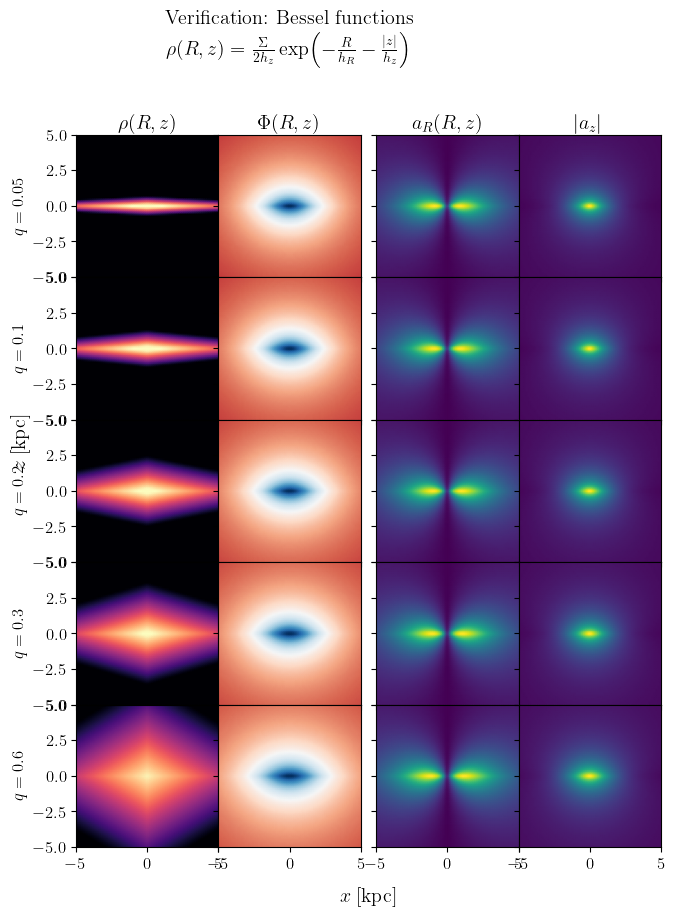

In [9]:
q_values = [0.05, 0.1, 0.2, 0.3, 0.6]

fig, axes = make_nx4_panel(
    nrows=len(q_values),
    gap=0.15,
    y_label_space=1.2,
    x_label_space=1.,
    xlabel=r"$x\;[\mathrm{kpc}]$",
    ylabel=r"$z\;[\mathrm{kpc}]$",
    title=title_text,
    margin_top = 0 
)

col_labels = [r"$\rho(R,z)$", r"$\Phi(R,z)$", r"$a_R(R,z)$", r"$|a_z|$"]
for c, lab in enumerate(col_labels):
    axes[0, c].set_title(lab, pad=4)

for row, q in enumerate(q_values):
    rho = rho_maps[q]
    phi = phi_maps[q]
    aR  = aR_maps[q]
    az  = az_maps[q]

    axes[row, 0].pcolormesh(X_grid, Z_grid, rho, shading="gouraud", cmap="magma",
        norm=mpl.colors.LogNorm(vmin=1e-5, vmax=1.0))

    phi_lim = np.abs(phi).max()
    axes[row, 1].pcolormesh(X_grid, Z_grid, phi, shading="gouraud", cmap="RdBu_r",
        norm=mpl.colors.Normalize(vmin=-phi_lim, vmax=0))

    axes[row, 2].pcolormesh(X_grid, Z_grid, aR, shading="gouraud", cmap="viridis",
        norm=mpl.colors.Normalize(vmin=0, vmax=aR.max()))

    axes[row, 3].pcolormesh(X_grid, Z_grid, az, shading="gouraud", cmap="viridis",
        norm=mpl.colors.Normalize(vmin=0, vmax=az.max()))

    axes[row, 0].set_ylabel(rf"$q={q}$", labelpad=4)



## Orbital computation 

In [12]:
# ---- Disk parameters from same column ----
M_d = 3.34e10
M_t = 0.84e10
hR_d = 2.241
hZ_d = 0.348
hR_t = 1.74
hZ_t = 0.858
# For rho = Sigma0/(2 hz) exp(-R/hR - |z|/hz), total mass = 2 pi Sigma0 hR^2
Sigma0_d = M_d / (2.0 * np.pi * hR_d**2)
Sigma0_t = M_t / (2.0 * np.pi * hR_t**2)

1058480558.0135611

In [24]:
# get some initial conditions 
tstrippy.potentials.clearaxisymmetricbasisexpansion()
tstrippy.potentials.initaxisymmetriccompositebasisexpansion(G, lmax, r_grid, ncomp)
tstrippy.potentials.addcompositebesselexponentialdisk(1,Sigma0_d,hR_d,hZ_d)
tstrippy.potentials.finalizecompositebasisexpansion()
radius = 34
eccen = 0.7
theta = np.pi/3
phi = np.pi
polar_mix = 0.1
xx,vv=tstrippy.code.orbits.apoapsis_shot(tstrippy.potentials.axisymmetriccompositebasispotential_dispatch,[],radius, eccen, theta, phi, polar_mix)
initialkinematics=[*xx,*vv]

In [ ]:
tstrippy.integrator.setintegrationparameters

In [ ]:
rho0=Sigma0_d/(2*hZ_d)
tcross = 1/np.sqrt(G*rho0)
integrationtime = 3*tcross
dt = 1e-3*tcross
NSTEP = int(integrationtime/dt)
integrationtime = dt*NSTEP
integrationparameters = [0,dt,NSTEP]

np.float64(7.690235559493767e-05)

In [ ]:
# G=tstrippy.io.potential_parameters.G
# tstrippy.integrator.clearaxisymmetriccompositebasisexpansion()
# tstrippy.integrator.addcompositebesselexponentialdisk(1, sigma0, hR, hz)
# tstrippy.integrator.finalizeaxisymmetriccompositebasisexpansion()


: 